# (강의) 선인장이미지분류 – ROC

최규빈  
2024-11-07

# 1. 강의영상

# 2. ref

## A. kaggle

ref: <https://www.kaggle.com/c/aerial-cactus-identification>

## B. 데이터 살펴보기

## C. 제출하기

# 3. imports

In [1]:
!pip uninstall -y mp2024pkg
!pip install git+https://github.com/guebin/mp2024pkg.git

Found existing installation: mp2024pkg 1.0
Uninstalling mp2024pkg-1.0:
  Successfully uninstalled mp2024pkg-1.0
  Cloning https://github.com/guebin/mp2024pkg.git to /tmp/pip-req-build-7atz0f96
  Running command git clone --filter=blob:none --quiet https://github.com/guebin/mp2024pkg.git /tmp/pip-req-build-7atz0f96
  Resolved https://github.com/guebin/mp2024pkg.git to commit a4fe1b53001396307c793830b1fcb371a92c55ca
  Preparing metadata (setup.py) ... done
  Created wheel for mp2024pkg: filename=mp2024pkg-1.0-py3-none-any.whl size=3362 sha256=87a3fe379d2a4ecd460b8aa8c9dbc1508fe7ae269817ca8b35a795cd8d584e87
  Stored in directory: /tmp/pip-ephem-wheel-cache-lb8oyecw/wheels/83/81/b1/63c03ca869bb1a35a588dce54e83ea32c6c21e6af0bbeaa640
Successfully built mp2024pkg

In [1]:
import mp2024pkg
#---#
import numpy as np
import pandas as pd 
import zipfile
import os
import PIL.Image
#---#
import datasets
import transformers
import torchvision.transforms
import evaluate
import torch

/home/cgb3/anaconda3/envs/hf/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

# 4. 예비학습

## A.

In [2]:
raw_data = datasets.Dataset.from_csv("./data/train.csv")
raw_data


Dataset({
    features: ['id', 'has_cactus'],
    num_rows: 17500
})

In [3]:
example = raw_data[0]
example 

{'id': '0004be2cfeaba1c0361d39e2b000257b.jpg', 'has_cactus': 1}

In [4]:
def m_transform(example):
    # example = {'id': xxx, 'has_cactus': yyy}
    example['path'] = f"./data/train/{example['id']}"
    example['label'] = example['has_cactus']
    del example['id']
    del example['has_cactus']
    return example

transformed_data = raw_data.map(m_transform)

In [5]:
print(transformed_data[0])
print(transformed_data[0:1])
print(transformed_data[0:2])

{'path': './data/train/0004be2cfeaba1c0361d39e2b000257b.jpg', 'label': 1}
{'path': ['./data/train/0004be2cfeaba1c0361d39e2b000257b.jpg'], 'label': [1]}
{'path': ['./data/train/0004be2cfeaba1c0361d39e2b000257b.jpg', './data/train/000c8a36845c0208e833c79c1bffedd1.jpg'], 'label': [1, 1]}

In [6]:
def w_transform(examples): 
    # examples = {'id': [xxx,xxxx,xxxxx], 'has_cactus': [yyy,yyyy,yyyyy]} 
    examples['paths'] = [f"./data/train/{i}" for i in examples['id']]
    examples['labels'] = [l for l in examples['has_cactus']]
    del examples['id']
    del examples['has_cactus']
    return examples
transformed_data = raw_data.with_transform(w_transform)
transformed_data

Dataset({
    features: ['id', 'has_cactus'],
    num_rows: 17500
})

In [7]:
print(transformed_data[0])
print(transformed_data[0:1])
print(transformed_data[0:2])

{'paths': './data/train/0004be2cfeaba1c0361d39e2b000257b.jpg', 'labels': 1}
{'paths': ['./data/train/0004be2cfeaba1c0361d39e2b000257b.jpg'], 'labels': [1]}
{'paths': ['./data/train/0004be2cfeaba1c0361d39e2b000257b.jpg', './data/train/000c8a36845c0208e833c79c1bffedd1.jpg'], 'labels': [1, 1]}

In [8]:
def s_transform(examples): 
    # examples = {'id': [xxx,xxxx,xxxxx], 'has_cactus': [yyy,yyyy,yyyyy]} 
    examples['paths'] = [f"./data/train/{i}" for i in examples['id']]
    examples['labels'] = [l for l in examples['has_cactus']]
    del examples['id']
    del examples['has_cactus']
    return examples
raw_data.set_transform(s_transform)


In [9]:
print(raw_data[0])
print(raw_data[0:1])
print(raw_data[0:2])

{'paths': './data/train/0004be2cfeaba1c0361d39e2b000257b.jpg', 'labels': 1}
{'paths': ['./data/train/0004be2cfeaba1c0361d39e2b000257b.jpg'], 'labels': [1]}
{'paths': ['./data/train/0004be2cfeaba1c0361d39e2b000257b.jpg', './data/train/000c8a36845c0208e833c79c1bffedd1.jpg'], 'labels': [1, 1]}

In [10]:
raw_data.reset_format()

In [11]:
print(raw_data[0])
print(raw_data[0:1])
print(raw_data[0:2])

{'id': '0004be2cfeaba1c0361d39e2b000257b.jpg', 'has_cactus': 1}
{'id': ['0004be2cfeaba1c0361d39e2b000257b.jpg'], 'has_cactus': [1]}
{'id': ['0004be2cfeaba1c0361d39e2b000257b.jpg', '000c8a36845c0208e833c79c1bffedd1.jpg'], 'has_cactus': [1, 1]}

# 5. Step1~2

## A. 압축풀기

In [12]:
mp2024pkg.tree(start_path='.')

├── .ipynb_checkpoints
│   ├── 2024-11-07-(강의) 선인장이미지분류 -- ROC-checkpoint.ipynb
│   └── 2024-11-07-(강의) 선인장이미지분류 ROC-checkpoint.ipynb
├── 2024-08-28-(강의) IMDB 자료 살펴보기, 지도학습의 개념.ipynb
├── 2024-08-29-image_classification-2.ipynb
└── ...
├── data
│   ├── sample_submission.csv
│   ├── test
│   │   ├── 000940378805c44108d287872b2f04ce.jpg
│   │   ├── 0017242f54ececa4512b4d7937d1e21e.jpg
│   │   ├── 001ee6d8564003107853118ab87df407.jpg
│   │   └── ...
│   │   ├── ffbd469c56873d064326204aac546e0d.jpg
│   │   ├── ffcb76b7d47f29ece11c751e5f763f52.jpg
│   │   └── fffed17d1a8e0433a934db518d7f532c.jpg
│   ├── train
│   │   ├── 0004be2cfeaba1c0361d39e2b000257b.jpg
│   │   ├── 000c8a36845c0208e833c79c1bffedd1.jpg
│   │   ├── 000d1e9a533f62e55c289303b072733d.jpg
│   │   └── ...
│   │   ├── fff059ecc91b30be5745e8b81111dc7b.jpg
│   │   ├── fff43acb3b7a23edcc4ae937be2b7522.jpg
│   │   └── fffd9e9b990eba07c836745d8aef1a3a.jpg
│   └── train.csv
├── model
│   └── 선인장분류
│       └── checkpoint-273
│         

In [13]:
!mkdir data

mkdir: cannot create directory ‘data’: File exists

In [14]:
mp2024pkg.tree(start_path='.')

├── .ipynb_checkpoints
│   ├── 2024-11-07-(강의) 선인장이미지분류 -- ROC-checkpoint.ipynb
│   └── 2024-11-07-(강의) 선인장이미지분류 ROC-checkpoint.ipynb
├── 2024-08-28-(강의) IMDB 자료 살펴보기, 지도학습의 개념.ipynb
├── 2024-08-29-image_classification-2.ipynb
└── ...
├── data
│   ├── sample_submission.csv
│   ├── test
│   │   ├── 000940378805c44108d287872b2f04ce.jpg
│   │   ├── 0017242f54ececa4512b4d7937d1e21e.jpg
│   │   ├── 001ee6d8564003107853118ab87df407.jpg
│   │   └── ...
│   │   ├── ffbd469c56873d064326204aac546e0d.jpg
│   │   ├── ffcb76b7d47f29ece11c751e5f763f52.jpg
│   │   └── fffed17d1a8e0433a934db518d7f532c.jpg
│   ├── train
│   │   ├── 0004be2cfeaba1c0361d39e2b000257b.jpg
│   │   ├── 000c8a36845c0208e833c79c1bffedd1.jpg
│   │   ├── 000d1e9a533f62e55c289303b072733d.jpg
│   │   └── ...
│   │   ├── fff059ecc91b30be5745e8b81111dc7b.jpg
│   │   ├── fff43acb3b7a23edcc4ae937be2b7522.jpg
│   │   └── fffd9e9b990eba07c836745d8aef1a3a.jpg
│   └── train.csv
├── model
│   └── 선인장분류
│       └── checkpoint-273
│         

In [15]:
# 압축 파일 풀기
with zipfile.ZipFile('aerial-cactus-identification.zip', 'r') as zip_ref:  # '파일명.zip'을 실제 파일명으로 변경
    zip_ref.extractall('./data')

In [16]:
mp2024pkg.tree(start_path='.')

├── .ipynb_checkpoints
│   ├── 2024-11-07-(강의) 선인장이미지분류 -- ROC-checkpoint.ipynb
│   └── 2024-11-07-(강의) 선인장이미지분류 ROC-checkpoint.ipynb
├── 2024-08-28-(강의) IMDB 자료 살펴보기, 지도학습의 개념.ipynb
├── 2024-08-29-image_classification-2.ipynb
└── ...
├── data
│   ├── sample_submission.csv
│   ├── test
│   │   ├── 000940378805c44108d287872b2f04ce.jpg
│   │   ├── 0017242f54ececa4512b4d7937d1e21e.jpg
│   │   ├── 001ee6d8564003107853118ab87df407.jpg
│   │   └── ...
│   │   ├── ffbd469c56873d064326204aac546e0d.jpg
│   │   ├── ffcb76b7d47f29ece11c751e5f763f52.jpg
│   │   └── fffed17d1a8e0433a934db518d7f532c.jpg
│   ├── test.zip
│   ├── train
│   │   ├── 0004be2cfeaba1c0361d39e2b000257b.jpg
│   │   ├── 000c8a36845c0208e833c79c1bffedd1.jpg
│   │   ├── 000d1e9a533f62e55c289303b072733d.jpg
│   │   └── ...
│   │   ├── fff059ecc91b30be5745e8b81111dc7b.jpg
│   │   ├── fff43acb3b7a23edcc4ae937be2b7522.jpg
│   │   └── fffd9e9b990eba07c836745d8aef1a3a.jpg
│   ├── train.csv
│   └── train.zip
├── model
│   └── 선인장분류
│ 

In [17]:
mp2024pkg.tree(start_path='./data')

├── sample_submission.csv
├── test
│   ├── 000940378805c44108d287872b2f04ce.jpg
│   ├── 0017242f54ececa4512b4d7937d1e21e.jpg
│   ├── 001ee6d8564003107853118ab87df407.jpg
│   └── ...
│   ├── ffbd469c56873d064326204aac546e0d.jpg
│   ├── ffcb76b7d47f29ece11c751e5f763f52.jpg
│   └── fffed17d1a8e0433a934db518d7f532c.jpg
├── test.zip
├── train
│   ├── 0004be2cfeaba1c0361d39e2b000257b.jpg
│   ├── 000c8a36845c0208e833c79c1bffedd1.jpg
│   ├── 000d1e9a533f62e55c289303b072733d.jpg
│   └── ...
│   ├── fff059ecc91b30be5745e8b81111dc7b.jpg
│   ├── fff43acb3b7a23edcc4ae937be2b7522.jpg
│   └── fffd9e9b990eba07c836745d8aef1a3a.jpg
├── train.csv
└── train.zip

In [18]:
with zipfile.ZipFile('./data/test.zip', 'r') as zip_ref:
    zip_ref.extractall('./data')    
with zipfile.ZipFile('./data/train.zip', 'r') as zip_ref:
    zip_ref.extractall('./data')    

In [19]:
mp2024pkg.tree(start_path='./data')

├── sample_submission.csv
├── test
│   ├── 000940378805c44108d287872b2f04ce.jpg
│   ├── 0017242f54ececa4512b4d7937d1e21e.jpg
│   ├── 001ee6d8564003107853118ab87df407.jpg
│   └── ...
│   ├── ffbd469c56873d064326204aac546e0d.jpg
│   ├── ffcb76b7d47f29ece11c751e5f763f52.jpg
│   └── fffed17d1a8e0433a934db518d7f532c.jpg
├── test.zip
├── train
│   ├── 0004be2cfeaba1c0361d39e2b000257b.jpg
│   ├── 000c8a36845c0208e833c79c1bffedd1.jpg
│   ├── 000d1e9a533f62e55c289303b072733d.jpg
│   └── ...
│   ├── fff059ecc91b30be5745e8b81111dc7b.jpg
│   ├── fff43acb3b7a23edcc4ae937be2b7522.jpg
│   └── fffd9e9b990eba07c836745d8aef1a3a.jpg
├── train.csv
└── train.zip

In [20]:
!rm ./data/test.zip ./data/train.zip

In [21]:
mp2024pkg.tree(start_path='./data')

├── sample_submission.csv
├── test
│   ├── 000940378805c44108d287872b2f04ce.jpg
│   ├── 0017242f54ececa4512b4d7937d1e21e.jpg
│   ├── 001ee6d8564003107853118ab87df407.jpg
│   └── ...
│   ├── ffbd469c56873d064326204aac546e0d.jpg
│   ├── ffcb76b7d47f29ece11c751e5f763f52.jpg
│   └── fffed17d1a8e0433a934db518d7f532c.jpg
├── train
│   ├── 0004be2cfeaba1c0361d39e2b000257b.jpg
│   ├── 000c8a36845c0208e833c79c1bffedd1.jpg
│   ├── 000d1e9a533f62e55c289303b072733d.jpg
│   └── ...
│   ├── fff059ecc91b30be5745e8b81111dc7b.jpg
│   ├── fff43acb3b7a23edcc4ae937be2b7522.jpg
│   └── fffd9e9b990eba07c836745d8aef1a3a.jpg
└── train.csv

## B. 모델

In [22]:
model = transformers.AutoModelForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=2,
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

In [23]:
mp2024pkg.signature(model.__call__)

In [24]:
mp2024pkg.signature(model.forward)

## C. 모델$($샘플자료$)$

In [25]:
!cat ./data/train.csv | head -n 5

id,has_cactus
0004be2cfeaba1c0361d39e2b000257b.jpg,1
000c8a36845c0208e833c79c1bffedd1.jpg,1
000d1e9a533f62e55c289303b072733d.jpg,1
0011485b40695e9138e92d0b3fb55128.jpg,1
cat: write error: Broken pipe

-   마지막은 오류는 무시해도 상관없음..

In [26]:
img1 = PIL.Image.open('./data/train/0004be2cfeaba1c0361d39e2b000257b.jpg')
img2 = PIL.Image.open('./data/train/000c8a36845c0208e833c79c1bffedd1.jpg')
label1 = 1 
label2 = 1 

In [27]:
f1 = torchvision.transforms.ToTensor()
f1(img1)

tensor([[[0.5333, 0.5255, 0.5765,  ..., 0.5961, 0.5765, 0.6157],
         [0.4863, 0.6314, 0.6196,  ..., 0.6392, 0.5765, 0.5686],
         [0.6314, 0.6275, 0.6196,  ..., 0.5882, 0.6314, 0.5059],
         ...,
         [0.5373, 0.7725, 0.4314,  ..., 0.6235, 0.5686, 0.6118],
         [0.5882, 0.6627, 0.5882,  ..., 0.6549, 0.5961, 0.5961],
         [0.7176, 0.4510, 0.6471,  ..., 0.7020, 0.5569, 0.5451]],

        [[0.5412, 0.5333, 0.5804,  ..., 0.5059, 0.4863, 0.5255],
         [0.4941, 0.6392, 0.6235,  ..., 0.5490, 0.4941, 0.4863],
         [0.6392, 0.6353, 0.6235,  ..., 0.5059, 0.5490, 0.4235],
         ...,
         [0.4353, 0.6706, 0.3294,  ..., 0.5176, 0.4627, 0.5059],
         [0.4863, 0.5608, 0.4863,  ..., 0.5490, 0.4824, 0.4824],
         [0.6157, 0.3490, 0.5451,  ..., 0.5882, 0.4431, 0.4314]],

        [[0.4902, 0.4902, 0.5490,  ..., 0.5294, 0.5098, 0.5490],
         [0.4431, 0.5961, 0.5922,  ..., 0.5725, 0.5137, 0.5059],
         [0.5882, 0.5922, 0.5922,  ..., 0.5255, 0.5686, 0.

In [28]:
f2 = torchvision.transforms.Resize(224)
f2(f1(img1)).shape

torch.Size([3, 224, 224])

In [29]:
f = torchvision.transforms.Compose([f1,f2])
model(
    pixel_values=torch.stack([f(img1),f(img2)]),
    labels=torch.tensor([1,1])
)

ImageClassifierOutput(loss=tensor(0.6659, grad_fn=<NllLossBackward0>), logits=tensor([[ 0.0405,  0.0433],
        [-0.0690,  0.0401]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [30]:
model_input = {'pixel_values':torch.stack([f(img1),f(img2)]), 'labels': torch.tensor([1,1])}
model(**model_input)    

ImageClassifierOutput(loss=tensor(0.6659, grad_fn=<NllLossBackward0>), logits=tensor([[ 0.0405,  0.0433],
        [-0.0690,  0.0401]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

## D. 전처리함수, 데이터콜랙터

In [31]:
examples = [
    dict(path = './data/train/0004be2cfeaba1c0361d39e2b000257b.jpg', label = 1),
    dict(path = './data/train/000c8a36845c0208e833c79c1bffedd1.jpg', label = 1) 
]

In [32]:
def collate_fn(examples): # [Dict,Dict,...] 
    imgs = [] 
    labels = [] 
    print(examples)
    for example in examples:
        imgs.append(PIL.Image.open(example['path']))
        labels.append(example['label'])
    f = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Resize(224)
    ])
    pixel_values = torch.stack([f(img) for img in imgs])
    labels = torch.tensor(labels)
    return dict(pixel_values=pixel_values,labels=labels)

In [33]:
collate_fn(examples)

[{'path': './data/train/0004be2cfeaba1c0361d39e2b000257b.jpg', 'label': 1}, {'path': './data/train/000c8a36845c0208e833c79c1bffedd1.jpg', 'label': 1}]

{'pixel_values': tensor([[[[0.5333, 0.5333, 0.5333,  ..., 0.6157, 0.6157, 0.6157],
           [0.5333, 0.5333, 0.5333,  ..., 0.6157, 0.6157, 0.6157],
           [0.5333, 0.5333, 0.5333,  ..., 0.6157, 0.6157, 0.6157],
           ...,
           [0.7176, 0.7176, 0.7176,  ..., 0.5451, 0.5451, 0.5451],
           [0.7176, 0.7176, 0.7176,  ..., 0.5451, 0.5451, 0.5451],
           [0.7176, 0.7176, 0.7176,  ..., 0.5451, 0.5451, 0.5451]],
 
          [[0.5412, 0.5412, 0.5412,  ..., 0.5255, 0.5255, 0.5255],
           [0.5412, 0.5412, 0.5412,  ..., 0.5255, 0.5255, 0.5255],
           [0.5412, 0.5412, 0.5412,  ..., 0.5255, 0.5255, 0.5255],
           ...,
           [0.6157, 0.6157, 0.6157,  ..., 0.4314, 0.4314, 0.4314],
           [0.6157, 0.6157, 0.6157,  ..., 0.4314, 0.4314, 0.4314],
           [0.6157, 0.6157, 0.6157,  ..., 0.4314, 0.4314, 0.4314]],
 
          [[0.4902, 0.4902, 0.4902,  ..., 0.5490, 0.5490, 0.5490],
           [0.4902, 0.4902, 0.4902,  ..., 0.5490, 0.5490, 0.5490],
        

In [34]:
model.to("cpu")
model(**collate_fn(examples))

[{'path': './data/train/0004be2cfeaba1c0361d39e2b000257b.jpg', 'label': 1}, {'path': './data/train/000c8a36845c0208e833c79c1bffedd1.jpg', 'label': 1}]

ImageClassifierOutput(loss=tensor(0.6659, grad_fn=<NllLossBackward0>), logits=tensor([[ 0.0405,  0.0433],
        [-0.0690,  0.0401]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [35]:
training_args = transformers.TrainingArguments(
    output_dir='./result/선인장이미지분류',
    remove_unused_columns=False, 
)
trainer_dummy = transformers.Trainer(
    model,
    training_args,
    data_collator=collate_fn,
)

In [36]:
trainer_dummy.predict(examples)

[{'path': './data/train/0004be2cfeaba1c0361d39e2b000257b.jpg', 'label': 1}, {'path': './data/train/000c8a36845c0208e833c79c1bffedd1.jpg', 'label': 1}]

PredictionOutput(predictions=array([[ 0.04047056,  0.04326881],
       [-0.06902013,  0.04014263]], dtype=float32), label_ids=array([1, 1]), metrics={'test_loss': 0.6659018993377686, 'test_model_preparation_time': 0.0016, 'test_runtime': 0.2948, 'test_samples_per_second': 6.784, 'test_steps_per_second': 3.392})

# 6. 코드정리

In [37]:
mp2024pkg.tree("./data")

├── sample_submission.csv
├── test
│   ├── 000940378805c44108d287872b2f04ce.jpg
│   ├── 0017242f54ececa4512b4d7937d1e21e.jpg
│   ├── 001ee6d8564003107853118ab87df407.jpg
│   └── ...
│   ├── ffbd469c56873d064326204aac546e0d.jpg
│   ├── ffcb76b7d47f29ece11c751e5f763f52.jpg
│   └── fffed17d1a8e0433a934db518d7f532c.jpg
├── train
│   ├── 0004be2cfeaba1c0361d39e2b000257b.jpg
│   ├── 000c8a36845c0208e833c79c1bffedd1.jpg
│   ├── 000d1e9a533f62e55c289303b072733d.jpg
│   └── ...
│   ├── fff059ecc91b30be5745e8b81111dc7b.jpg
│   ├── fff43acb3b7a23edcc4ae937be2b7522.jpg
│   └── fffd9e9b990eba07c836745d8aef1a3a.jpg
└── train.csv

## A. 정리1 – 콜렉터로 다함..

In [78]:
train_csv = pd.read_csv("./data/train.csv")
label = train_csv.has_cactus
path = train_csv['id'].map(lambda x: f'./data/train/{x}')
원시데이터 = raw_data = [dict(label=l, path=p) for l,p in zip(label,path)]

In [79]:
이미지처리하기 = torchvision.transforms.Compose([
    torchvision.transforms.Lambda(lambda path_str: PIL.Image.open(path_str)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(224),
])

In [80]:
이미지처리하기('./data/train/fffd9e9b990eba07c836745d8aef1a3a.jpg')

tensor([[[0.6902, 0.6902, 0.6902,  ..., 0.6353, 0.6353, 0.6353],
         [0.6902, 0.6902, 0.6902,  ..., 0.6353, 0.6353, 0.6353],
         [0.6902, 0.6902, 0.6902,  ..., 0.6353, 0.6353, 0.6353],
         ...,
         [0.6275, 0.6275, 0.6275,  ..., 0.3647, 0.3647, 0.3647],
         [0.6275, 0.6275, 0.6275,  ..., 0.3647, 0.3647, 0.3647],
         [0.6275, 0.6275, 0.6275,  ..., 0.3647, 0.3647, 0.3647]],

        [[0.5804, 0.5804, 0.5804,  ..., 0.5059, 0.5059, 0.5059],
         [0.5804, 0.5804, 0.5804,  ..., 0.5059, 0.5059, 0.5059],
         [0.5804, 0.5804, 0.5804,  ..., 0.5059, 0.5059, 0.5059],
         ...,
         [0.5882, 0.5882, 0.5882,  ..., 0.3843, 0.3843, 0.3843],
         [0.5882, 0.5882, 0.5882,  ..., 0.3843, 0.3843, 0.3843],
         [0.5882, 0.5882, 0.5882,  ..., 0.3843, 0.3843, 0.3843]],

        [[0.6392, 0.6392, 0.6392,  ..., 0.5804, 0.5804, 0.5804],
         [0.6392, 0.6392, 0.6392,  ..., 0.5804, 0.5804, 0.5804],
         [0.6392, 0.6392, 0.6392,  ..., 0.5804, 0.5804, 0.

In [81]:
def collate_fn(examples):
    # examples = [Dict_1, Dict_2, ...., Dict_n] 
    # examples = 원시데이터 
    #          = [원시데이터_1, 원시데이터_2, ..., 원시데이터_n] 
    #          = [{'label':, 'path':}, {'label':, 'path':}, ..., {'label':, 'path':}]  
    model_inputs = dict(
        labels = torch.tensor([o['label'] for o in examples]),
        pixel_values = torch.stack([이미지처리하기(o['path']) for o in examples])
    )
    return model_inputs    
모델입력구성하기 = collate_fn

In [82]:
모델 = model = transformers.AutoModelForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=2,
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

In [83]:
accuracy = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)
training_args = transformers.TrainingArguments(
    output_dir="./model/선인장분류",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    #metric_for_best_model="accuracy",
    push_to_hub=False,
    report_to="none"
)
트레이너 = trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    train_dataset=raw_data,
    eval_dataset=raw_data, # 검증자료가 따로 없다는 의미
    #tokenizer=image_processor,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

TrainOutput(global_step=273, training_loss=0.006133950627562436, metrics={'train_runtime': 179.0913, 'train_samples_per_second': 97.716, 'train_steps_per_second': 1.524, 'total_flos': 1.3539400425461514e+18, 'train_loss': 0.006133950627562436, 'epoch': 0.9981718464351006})

## B. 정리2 – 전처리로 다함..

In [87]:
raw_data = datasets.Dataset.from_csv("./data/train.csv")
raw_data


Dataset({
    features: ['id', 'has_cactus'],
    num_rows: 17500
})

In [88]:
example = raw_data[0]
example 

{'id': '0004be2cfeaba1c0361d39e2b000257b.jpg', 'has_cactus': 1}

In [89]:
def m_transform1(example):
    # example = {'id': xxx, 'has_cactus': yyy}
    example['path'] = f"./data/train/{example['id']}"
    example['label'] = example['has_cactus']
    del example['id']
    del example['has_cactus']
    return example

raw_data2 = raw_data.map(m_transform1)

In [90]:
print(raw_data2[0])
print(raw_data2[0:1])
print(raw_data2[0:2])

{'path': './data/train/0004be2cfeaba1c0361d39e2b000257b.jpg', 'label': 1}
{'path': ['./data/train/0004be2cfeaba1c0361d39e2b000257b.jpg'], 'label': [1]}
{'path': ['./data/train/0004be2cfeaba1c0361d39e2b000257b.jpg', './data/train/000c8a36845c0208e833c79c1bffedd1.jpg'], 'label': [1, 1]}

In [91]:
def m_transform2(example):
    # example = {'path': xxx, 'label': yyy}
    example['image'] = PIL.Image.open(example['path'])
    return example

raw_data3 = raw_data2.map(m_transform2)

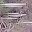

In [92]:
raw_data3[0]['image']

In [93]:
raw_data4 = raw_data3.remove_columns(['path'])

In [94]:
raw_data4

Dataset({
    features: ['label', 'image'],
    num_rows: 17500
})

In [95]:
이미지처리하기 = torchvision.transforms.Compose([
#    torchvision.transforms.Lambda(lambda path_str: PIL.Image.open(path_str)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(224),
])

In [96]:
def w_transform(examples): 
    # examples = {'label': [xxx,xxxx,xxxxx], 'image': [yyy,yyyy,yyyyy]} 
    examples['pixel_values'] = torch.stack(list(map(이미지처리하기,examples['image'])))
    examples['labels'] = torch.tensor(examples['label'])
    del examples['label'] 
    del examples['image'] 
    return examples
transformed_data = raw_data4.with_transform(w_transform)
transformed_data

Dataset({
    features: ['label', 'image'],
    num_rows: 17500
})

In [97]:
transformed_data[0]

{'pixel_values': tensor([[[0.5333, 0.5333, 0.5333,  ..., 0.6157, 0.6157, 0.6157],
          [0.5333, 0.5333, 0.5333,  ..., 0.6157, 0.6157, 0.6157],
          [0.5333, 0.5333, 0.5333,  ..., 0.6157, 0.6157, 0.6157],
          ...,
          [0.7176, 0.7176, 0.7176,  ..., 0.5451, 0.5451, 0.5451],
          [0.7176, 0.7176, 0.7176,  ..., 0.5451, 0.5451, 0.5451],
          [0.7176, 0.7176, 0.7176,  ..., 0.5451, 0.5451, 0.5451]],
 
         [[0.5412, 0.5412, 0.5412,  ..., 0.5255, 0.5255, 0.5255],
          [0.5412, 0.5412, 0.5412,  ..., 0.5255, 0.5255, 0.5255],
          [0.5412, 0.5412, 0.5412,  ..., 0.5255, 0.5255, 0.5255],
          ...,
          [0.6157, 0.6157, 0.6157,  ..., 0.4314, 0.4314, 0.4314],
          [0.6157, 0.6157, 0.6157,  ..., 0.4314, 0.4314, 0.4314],
          [0.6157, 0.6157, 0.6157,  ..., 0.4314, 0.4314, 0.4314]],
 
         [[0.4902, 0.4902, 0.4902,  ..., 0.5490, 0.5490, 0.5490],
          [0.4902, 0.4902, 0.4902,  ..., 0.5490, 0.5490, 0.5490],
          [0.4902, 0.490

In [73]:
모델 = model = transformers.AutoModelForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=2,
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

In [76]:
accuracy = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)
training_args = transformers.TrainingArguments(
    output_dir="./model/선인장분류",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    #metric_for_best_model="accuracy",
    push_to_hub=False,
    report_to="none"
)
트레이너 = trainer = transformers.Trainer(
    model=model,
    args=training_args,
#    data_collator=collate_fn,
    train_dataset=transformed_data,
    eval_dataset=transformed_data, # 검증자료가 따로 없다는 의미
    #tokenizer=image_processor,
    compute_metrics=compute_metrics,
)

In [77]:
trainer.train()

TrainOutput(global_step=273, training_loss=0.07866512768434518, metrics={'train_runtime': 181.7643, 'train_samples_per_second': 96.279, 'train_steps_per_second': 1.502, 'total_flos': 1.3539400425461514e+18, 'train_loss': 0.07866512768434518, 'epoch': 0.9981718464351006})